# Introduction to LangChain

## What is LangChain?

LangChain is an open-source framework for building applications powered by Large Language Models (LLMs).

Instead of directly sending prompts to an LLM, LangChain provides building blocks that allow us to create complete AI applications by connecting:

* LLMs
* Prompt templates
* Output parsers
* Tools
* APIs
* Vector databases
* Retrievers
* Agents
* Workflows
* Conversation history
  
  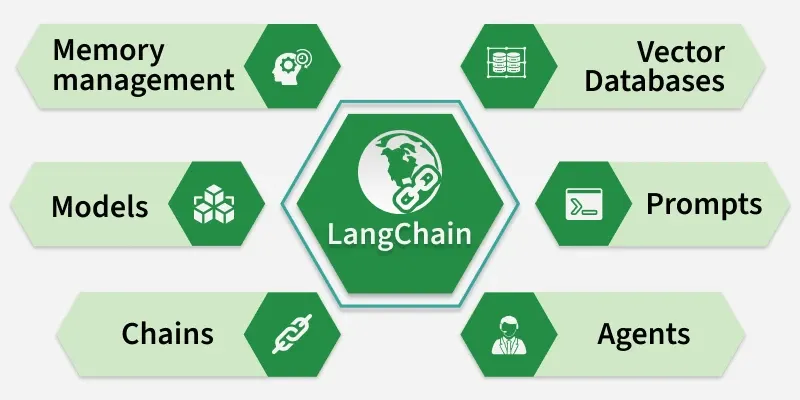

LangChain is available for both **Python** and **JavaScript/TypeScript**.

### Why do we need LangChain?

Suppose we want to build an AI application that:

1. Accepts a user's question
2. Retrieves information from a database
3. Sends that information to an LLM
4. Generates an answer
5. Remembers previous conversation

We could implement all of this manually.

LangChain provides reusable components that make this process easier and more structured.

---

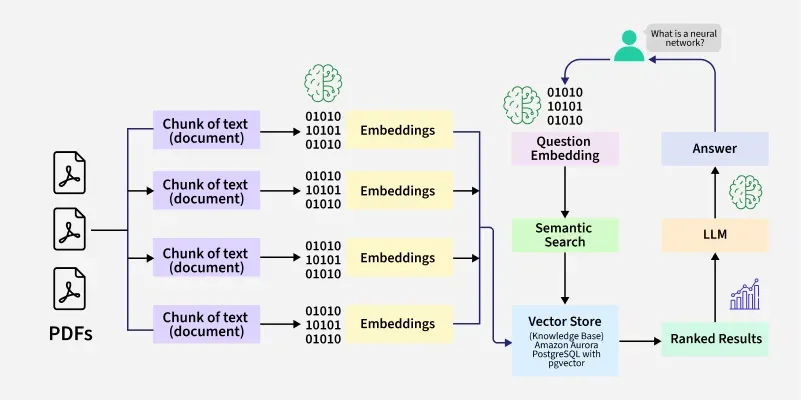

# Key Components of LangChain

The major concepts we will work with are:

## 1. Models

Models are the LLMs that generate responses.

LangChain provides a common interface for interacting with different model providers.

For example:

* OpenAI
* Anthropic
* Google Gemini
* Hugging Face
* Ollama
* Many other providers

In this workshop, we will use **ChatOpenAI**.

```python
from langchain_openai import ChatOpenAI
```

---

## 2. Prompt Templates

Prompt templates allow us to create reusable prompts.

Instead of writing:

```text
Give me 3 career skills that are in high demand in 2026.
```

we can create:

```text
Give me 3 career skills that are in high demand in {year}.
```

Now `{year}` can be replaced dynamically.

This is useful when building applications where the input changes.

---

## 3. Output Parsers

LLMs return structured message objects.

Output parsers allow us to convert model output into a convenient format.

For example:

```python
from langchain_core.output_parsers import StrOutputParser
```

`StrOutputParser` converts the model's response into a normal Python string.

---

## 4. Chains

A chain connects multiple operations together.

For example:

```text
Prompt → LLM → Output Parser
```

LangChain allows us to express this using the pipe operator:

```python
chain = prompt_template | llm | parser
```

This is part of **LangChain Expression Language (LCEL)**.

---

## 5. Agents

Agents allow an LLM to decide which action or tool should be used.

For example:

```text
User Question
      ↓
     LLM
      ↓
Decide what to do
      ↓
 ┌────┴─────┐
 ↓          ↓
Search     Calculator
 ↓          ↓
 └────┬─────┘
      ↓
     LLM
      ↓
   Response
```

Agents are useful when the application needs to interact with external tools or APIs.

---

## 6. Vector Stores

Vector stores are commonly used in **Retrieval-Augmented Generation (RAG)** applications.

Documents are converted into embeddings and stored as vectors.

When a user asks a question, the question is also converted into a vector.

The system then searches for documents that are semantically similar to the question.

Common vector stores include:

* FAISS
* Chroma
* Pinecone
* Weaviate
* Qdrant

---

## 7. Memory / Conversation History

AI applications often need to remember previous messages.

For example:

```text
User: My name is Rajendra.

AI: Nice to meet you, Rajendra.

User: What is my name?

AI: Your name is Rajendra.
```

Conversation history allows applications to maintain context between interactions.

Modern LangChain applications can also use LangGraph for more advanced stateful workflows.

---

# How LangChain Works

A simple LangChain application can be represented as:

```text
User Input
    ↓
Prompt Template
    ↓
LLM
    ↓
Output Parser
    ↓
Final Response
```

For a RAG application, the architecture becomes:

```text
             Documents
                 ↓
          Document Loader
                 ↓
         Text Splitter
                 ↓
             Embeddings
                 ↓
           Vector Store
                 ↓
User Query → Retriever
                 ↓
          Relevant Context
                 ↓
           Prompt Template
                 ↓
                LLM
                 ↓
             Response
```

---

# Workshop Example

In this workshop, we will build a simple LangChain application using:

* Python
* LangChain
* OpenAI
* PromptTemplate
* ChatOpenAI
* StrOutputParser
* LCEL

Our application will generate **three career skills that are in high demand in a given year**.

---

# Step 1: Install Dependencies

Install LangChain and the OpenAI integration.

```bash
pip install langchain langchain-openai
```

### Packages

### `langchain`

Provides the core LangChain framework.

### `langchain-openai`

Provides the integration between LangChain and OpenAI models.

It gives us classes such as:

```python
ChatOpenAI
```

---

# Step 2: Import Libraries

Import the components required for our application.

```python
from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
```

Let's understand each import.

### ChatOpenAI

```python
from langchain_openai import ChatOpenAI
```

`ChatOpenAI` allows LangChain to communicate with OpenAI chat models.

---

### PromptTemplate

```python
from langchain_core.prompts import PromptTemplate
```

`PromptTemplate` allows us to create reusable prompts containing variables.

For example:

```text
Give me 3 career skills that are in high demand in {year}.
```

Here:

```text
{year}
```

is a variable.

---

### StrOutputParser

```python
from langchain_core.output_parsers import StrOutputParser
```

This parser converts the model's output into a simple string.

---

# Step 3: Configure the OpenAI API Key

We need an OpenAI API key to access the model.

For a workshop, we can demonstrate the key using an environment variable.

Create a `.env` file:

```text
OPENAI_API_KEY=your_api_key_here
```

### Important

Do not commit your API key to GitHub.

Add `.env` to `.gitignore`:

```text
.env
```

Then load the environment variable.

One simple approach is:

```bash
pip install python-dotenv
```

Then:

```python
from dotenv import load_dotenv

load_dotenv()
```

LangChain/OpenAI can then read the `OPENAI_API_KEY` environment variable.

---

# Step 4: Initialize ChatOpenAI

Now we create our LLM.

```python
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.7
)
```

## Understanding the parameters

### `model`

```python
model="gpt-4o-mini"
```

Specifies the OpenAI model we want to use.

The exact model available to your API account can change, so use a currently supported OpenAI model in your environment.

---

### `temperature`

```python
temperature=0.7
```

Controls the randomness of the generated response.

A simplified interpretation:

```text
0.0  → More deterministic
0.3  → Low creativity
0.7  → More creative
1.0  → Higher randomness
```

For factual or deterministic applications, a lower temperature is often preferred.

For creative applications, a higher temperature can be useful.

---

# Step 5: Run a Simple Prompt

Before creating a chain, let's directly invoke the model.

```python
response = llm.invoke(
    "Suggest me a skill that is in demand."
)

print(response)
```

The model returns an AI message object.

You may see output similar to:

```text
content='Artificial Intelligence and Machine Learning'
```

The important part is the `content`.

---

# What does `.invoke()` mean?

`.invoke()` sends an input to a LangChain component and waits for the result.

For example:

```python
response = llm.invoke("Hello")
```

Conceptually:

```text
Python Program
      ↓
    invoke()
      ↓
  ChatOpenAI
      ↓
    OpenAI
      ↓
   AI Response
```

---

# Step 6: Create a Prompt Template

Now let's make our prompt reusable.

```python
template = """
Give me 3 career skills that are in high demand in {year}.
"""

prompt_template = PromptTemplate.from_template(template)
```

Our prompt contains a variable:

```text
{year}
```

We can provide a different value every time we invoke the prompt.

For example:

```python
prompt_template.invoke({"year": "2026"})
```

This produces a prompt equivalent to:

```text
Give me 3 career skills that are in high demand in 2026.
```

---

# Step 7: Create an Output Parser

Create a string output parser:

```python
parser = StrOutputParser()
```

Why do we need it?

The LLM returns a message object.

The parser extracts the actual textual content.

Conceptually:

```text
AIMessage
   ↓
StrOutputParser
   ↓
String
```

---

# Step 8: Build a Chain

Now we connect everything together.

```python
chain = prompt_template | llm | parser
```

This is one of the most important concepts in LangChain.

The `|` operator is used to connect components.

Our chain is:

```text
PromptTemplate
      ↓
   ChatOpenAI
      ↓
StrOutputParser
      ↓
    String
```

---

# Understanding LCEL

LCEL stands for:

**LangChain Expression Language**

It provides a simple way to compose LangChain components.

For example:

```python
chain = prompt_template | llm | parser
```

means:

```text
Input
  ↓
PromptTemplate
  ↓
ChatOpenAI
  ↓
StrOutputParser
  ↓
Output
```

This is much cleaner than manually calling every component.

Without a chain, we could write:

```python
prompt = prompt_template.invoke({"year": "2026"})

response = llm.invoke(prompt)

result = parser.invoke(response)

print(result)
```

With LCEL:

```python
result = chain.invoke({"year": "2026"})

print(result)
```

The chain handles the flow between the components.

---

# Step 9: Invoke the Chain

Now let's execute the complete chain.

```python
response = chain.invoke({
    "year": "2026"
})

print(response)
```

Possible output:

```text
1. Artificial Intelligence and Machine Learning
2. Data Analytics
3. Cybersecurity
```

The exact answer will vary because it is generated by the LLM.

---

# Complete Workshop Code

Here is the complete example:

```python
from dotenv import load_dotenv

from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser


# Load environment variables
load_dotenv()


# Initialize the OpenAI model
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.7
)


# Create prompt template
template = """
Give me 3 career skills that are in high demand in {year}.
"""

prompt_template = PromptTemplate.from_template(template)


# Create output parser
parser = StrOutputParser()


# Build LangChain pipeline
chain = prompt_template | llm | parser


# Run the chain
response = chain.invoke({
    "year": "2026"
})


# Display result
print("Career Skills in 2026:")
print(response)
```

---

# Understanding the Complete Flow

Let's break the complete program down:

```text
                  User Input
                      │
                      │
                 year = 2026
                      │
                      ▼
              PromptTemplate
                      │
                      │
                      ▼
       "Give me 3 career skills
        in high demand in 2026."
                      │
                      ▼
                 ChatOpenAI
                      │
                      ▼
               OpenAI Model
                      │
                      ▼
                AI Message
                      │
                      ▼
             StrOutputParser
                      │
                      ▼
              Final String
```

This is the fundamental idea behind LangChain:

> **Connect reusable components to create an LLM-powered workflow.**

---

# Why Use LangChain Instead of Calling an LLM Directly?

Without LangChain:

```python
response = client.chat.completions.create(...)
```

You directly communicate with the model.

This is perfectly valid for simple applications.

However, as the application becomes more complex, we may need:

```text
LLM
 ↓
Prompt
 ↓
Retriever
 ↓
Database
 ↓
Tools
 ↓
Another LLM
 ↓
Parser
 ↓
Application
```

LangChain provides abstractions for connecting these components.

---

# From Simple Chain to RAG

The example above is a simple LLM chain.

We can extend it into a RAG application.

For example, suppose we have:

```text
resume.pdf
```

We can build:

```text
PDF
 ↓
Document Loader
 ↓
Text Splitter
 ↓
Embeddings
 ↓
Vector Database
 ↓
Retriever
 ↓
Prompt
 ↓
ChatOpenAI
 ↓
Answer
```

Then a user could ask:

```text
What technical skills are mentioned in my resume?
```

The system retrieves relevant resume content and provides it to the LLM.

---

# From RAG to Agents

We can also introduce tools.

For example, an AI assistant could have:

```text
              User
                ↓
               LLM
                ↓
        Decide what to do
          /     |      \
         /      |       \
     Search Calculator Database
         \      |       /
          \     |      /
                ↓
               LLM
                ↓
             Answer
```

This is where agents become useful.

---

# Important LangChain Concepts to Remember

| Concept           | Purpose                                     |
| ----------------- | ------------------------------------------- |
| `ChatOpenAI`      | Connect to an OpenAI chat model             |
| `PromptTemplate`  | Create reusable prompts                     |
| `StrOutputParser` | Convert output to a string                  |
| `Runnable`        | A component that can participate in a chain |
| `LCEL`            | Compose components using `\|`               |
| `Chain`           | Connect multiple operations                 |
| `Retriever`       | Retrieve relevant information               |
| `Vector Store`    | Store and search embeddings                 |
| `Agent`           | Decide which tools/actions to use           |
| `Memory/State`    | Maintain conversation or workflow context   |

---

# Workshop Exercise

Try modifying the prompt.

### Exercise 1

Change:

```python
template = """
Give me 3 career skills that are in high demand in {year}.
"""
```

to:

```python
template = """
Give me 5 programming languages that are popular in {year}.
"""
```

Then run:

```python
response = chain.invoke({
    "year": "2026"
})
```

---

## Exercise 2 — Add Another Variable

Create a prompt:

```text
Suggest 5 career skills for a {role} in {year}.
```

Then invoke:

```python
response = chain.invoke({
    "role": "Software Engineer",
    "year": "2026"
})
```

---

## Exercise 3 — Experiment with Temperature

Try:

```python
temperature=0
```

and then:

```python
temperature=1
```

Compare the responses.

Think about:

* Which response is more consistent?
* Which response is more creative?
* Which temperature would you choose for a factual application?

---

# Key Takeaways

By the end of this section, you should understand:

1. What LangChain is
2. Why LangChain is useful
3. How LangChain connects LLMs with other components
4. How to use `ChatOpenAI`
5. How to create reusable prompts using `PromptTemplate`
6. How to parse model output using `StrOutputParser`
7. How `.invoke()` works
8. What LCEL is
9. How the `|` operator creates a pipeline
10. How a simple chain can later evolve into RAG and agent-based applications

The most important pattern to remember is:

```python
prompt | llm | parser
```

or conceptually:

```text
Input
  ↓
Prompt
  ↓
LLM
  ↓
Parser
  ↓
Output
```

This simple pattern is the foundation for building more advanced LangChain applications.
